In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36739")
client

<Client: 'tcp://127.0.0.1:36739' processes=10 threads=80, memory=80.00 GiB>

In [2]:
import numpy as np
import xarray as xr
import os.path as op
from xgcm.grid import Grid

import xrft

# from xmovie import Movie

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
ddir = "/app/Oceananigans/"
bdir = "/app/Oceananigans/barotropic/"

In [4]:
dt = 20.
f0 = 1e-4

iiter = 2
# ds = xr.open_zarr(op.join(ddir, 
#             "ocean_wind_mixing_and_convection/bottom-drag/Z1km/"
#             + "384x384x64/Q200/output.%04d.zarr" % iiter
#                          )
#                  )
ds = xr.open_dataset(op.join(ddir, 
                     "ocean_wind_mixing_and_convection/"
                     + "bottom-drag/Z2km/512x512x64/Q200/spinup.v1.12.%04d.nc"
                             % iiter
                            ),
                     chunks={"z_aaf":-1,"z_aac":-1,
                             "y_afa":64,"x_faa":64,
                             "x_caa":64,"y_aca":64
                            }
     )

grid = Grid(ds, 
            periodic=['X', 'Y'], autoparse_metadata=False,
            coords={'X': {'left': 'x_faa', 'center': 'x_caa'},
                    'Y': {'left': 'y_afa', 'center': 'y_aca'},
                    'Z': {'center': 'z_aac', 'outer': 'z_aaf'}
                   }
           )
gridz = Grid(ds, periodic=False, autoparse_metadata=False,
             coords={'X': {'left': 'x_faa', 'center': 'x_caa'},
                     'Y': {'left': 'y_afa', 'center': 'y_aca'},
                     'Z': {'center': 'z_aac', 'outer': 'z_aaf'}
                    }
            )
ds, grid

/tmp/ipykernel_48554/3156032742.py:10: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(op.join(ddir,
/tmp/ipykernel_48554/3156032742.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "y_aca" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(op.join(ddir,
/tmp/ipykernel_48554/3156032742.py:10: UserWarning: The specified chunks separate the stored chunks along di

(<xarray.Dataset> Size: 2GB
 Dimensions:  (x_caa: 512, x_faa: 512, y_aca: 512, y_afa: 512, z_aac: 64,
               z_aaf: 65, time: 7)
 Coordinates:
   * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
   * y_afa    (y_afa) float64 4kB -1e+05 -9.961e+04 ... 9.922e+04 9.961e+04
   * x_faa    (x_faa) float64 4kB 0.0 390.6 781.2 ... 1.992e+05 1.996e+05
   * x_caa    (x_caa) float64 4kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
   * y_aca    (y_aca) float64 4kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
   * z_aaf    (z_aaf) float64 520B -2e+03 -1.877e+03 -1.764e+03 ... -10.5 0.0
   * z_aac    (z_aac) float64 512B -1.939e+03 -1.82e+03 ... -15.77 -5.251
 Data variables:
     Δx_caa   (x_caa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
     Δx_faa   (x_faa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
     Δy_aca   (y_aca) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
     Δy_afa   (y_afa) float32 2kB dask.array<chunksize=(64,), meta=

In [5]:
izc = 32
ds.isel(z_aac=izc)

<xarray.Dataset> Size: 506MB
Dimensions:  (x_caa: 512, x_faa: 512, y_aca: 512, y_afa: 512, z_aaf: 65, time: 7)
Coordinates:
  * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
  * y_afa    (y_afa) float64 4kB -1e+05 -9.961e+04 ... 9.922e+04 9.961e+04
  * x_faa    (x_faa) float64 4kB 0.0 390.6 781.2 ... 1.992e+05 1.996e+05
  * x_caa    (x_caa) float64 4kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
  * y_aca    (y_aca) float64 4kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
  * z_aaf    (z_aaf) float64 520B -2e+03 -1.877e+03 -1.764e+03 ... -10.5 0.0
    z_aac    float64 8B -391.6
Data variables:
    Δx_caa   (x_caa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δx_faa   (x_faa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δy_aca   (y_aca) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δy_afa   (y_afa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δz_aac   float32 4B dask.array<chunksize=(), meta=np.ndarray>
    Δz_aaf   (z_aaf) float32 260B dask.array<chunksize=(65,), meta=np.ndarray>
    b        (time, y_aca, x_caa) float32 7MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    e        (time, y_aca, x_caa) float32 7MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    u        (time, y_aca, x_faa) float32 7MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    v        (time, y_afa, x_caa) float32 7MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    w        (time, z_aaf, y_aca, x_caa) float32 477MB dask.array<chunksize=(1, 65, 64, 64), meta=np.ndarray>
Attributes:
    Julia:                 This file was generated using CUDA GPU: NVIDIA GeF...
    Oceananigans:          This file was generated using Oceananigans v0.105.3
    date:                  This file was generated on 2026-03-12T07:50:55.227...
    interval:              864000.0
    output time interval:  Output was saved every 10 days.
    schedule:              TimeInterval

In [6]:
dspp = xr.open_zarr(op.join(ddir, 
                "ocean_wind_mixing_and_convection/bottom-drag/Z2km/"
                + "512x512x64/Q200/spinup/Upp.%04d.zarr" % iiter
                           )
                   )
dspp

<xarray.Dataset> Size: 3GB
Dimensions:  (y_aca: 512, x_caa: 512, z_aac: 64, time: 7, x_faa: 512,
              y_afa: 512, z_aaf: 65)
Coordinates:
  * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
  * x_caa    (x_caa) float64 4kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
  * x_faa    (x_faa) float64 4kB 0.0 390.6 781.2 ... 1.992e+05 1.996e+05
  * y_aca    (y_aca) float64 4kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
  * y_afa    (y_afa) float64 4kB -1e+05 -9.961e+04 ... 9.922e+04 9.961e+04
  * z_aac    (z_aac) float64 512B -1.939e+03 -1.82e+03 ... -15.77 -5.251
  * z_aaf    (z_aaf) float64 520B -2e+03 -1.877e+03 -1.764e+03 ... -10.5 0.0
Data variables:
    bhash    (y_aca, x_caa, z_aac) float64 134MB dask.array<chunksize=(512, 512, 1), meta=np.ndarray>
    Piflat   (time, y_aca, x_caa, z_aac) float64 940MB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>
    Pip      (time, z_aac, y_aca, x_caa) float32 470MB dask.array<chunksize=(1, 1, 512, 512), meta=np.ndarray>
    upp      (time, y_aca, x_faa, z_aac) float32 470MB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>
    vpp      (time, y_afa, x_caa, z_aac) float32 470MB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>
    wflat    (time, y_aca, x_caa, z_aaf) float64 954MB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>

In [7]:
up = (ds.u - ds.u.mean("time")
     ).chunk({"z_aac":1,"y_aca":-1,"x_faa":-1})
vp = (ds.v - ds.v.mean("time")
     ).chunk({"z_aac":1,"y_afa":-1,"x_caa":-1})
wp = (ds.w - ds.w.mean("time")
     ).chunk({"z_aaf":-1,"y_aca":-1, "x_caa":-1})

In [8]:
Fup = xrft.isotropic_power_spectrum(up, 
                                    dim=["y_aca","x_faa"], detrend="constant", 
                                    truncate=True
                                   )
Fvp = xrft.isotropic_power_spectrum(vp, 
                                    dim=["y_afa","x_caa"], detrend="constant", 
                                    truncate=True
                                   )
Fupp = xrft.isotropic_power_spectrum(dspp.upp.isel(z_aac=izc), 
                                     dim=["y_aca","x_faa"], detrend="constant", 
                                     truncate=True
                                    )
Fvpp = xrft.isotropic_power_spectrum(dspp.vpp.isel(z_aac=izc), 
                                     dim=["y_afa","x_caa"], detrend="constant", 
                                     truncate=True
                                    )
Ep = .5*(Fup + Fvp)
Epp = .5*(Fupp + Fvpp)
Ep, Epp

(<xarray.DataArray (time: 7, z_aac: 64, freq_r: 90)> Size: 323kB
 dask.array<mul, shape=(7, 64, 90), dtype=float64, chunksize=(1, 1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
   * z_aac    (z_aac) float64 512B -1.939e+03 -1.82e+03 ... -15.77 -5.251
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266,
 <xarray.DataArray (time: 7, freq_r: 90)> Size: 5kB
 dask.array<mul, shape=(7, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
     z_aac    float64 8B -391.6
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266)

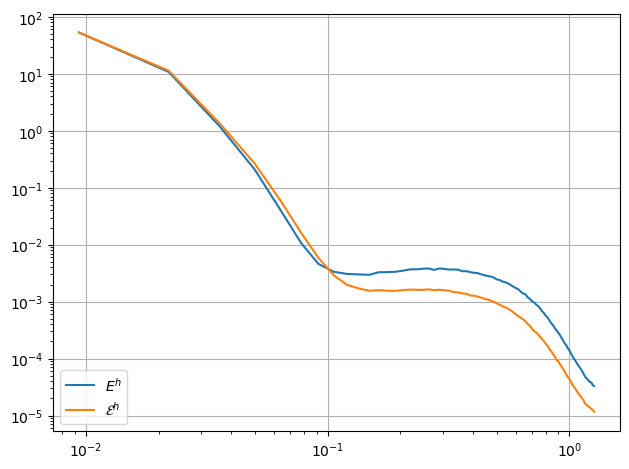

In [9]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
ax.plot(Ep.freq_r*1e3, Ep.isel(z_aac=izc).mean("time"), label=r"$E^h$")
ax.plot(Epp.freq_r*1e3, Epp.mean("time"), label=r"$\mathcal{E}^h$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left")
ax.grid(True)

In [10]:
Fwp = xrft.isotropic_power_spectrum(wp.chunk({"z_aaf":1,"y_aca":-1,"x_caa":-1}), 
                                    dim=["y_aca","x_caa"], detrend="constant", 
                                    truncate=True
                                   )
Fws = xrft.isotropic_power_spectrum(dspp.wflat.isel(z_aaf=izc), 
                                    dim=["y_aca","x_caa"], detrend="constant", 
                                    truncate=True
                                   )
Fwp, Fws

(<xarray.DataArray (time: 7, z_aaf: 65, freq_r: 90)> Size: 328kB
 dask.array<getitem, shape=(7, 65, 90), dtype=float64, chunksize=(1, 1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
   * z_aaf    (z_aaf) float64 520B -2e+03 -1.877e+03 -1.764e+03 ... -10.5 0.0
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266,
 <xarray.DataArray (time: 7, freq_r: 90)> Size: 5kB
 dask.array<getitem, shape=(7, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
     z_aaf    float64 8B -400.2
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266)

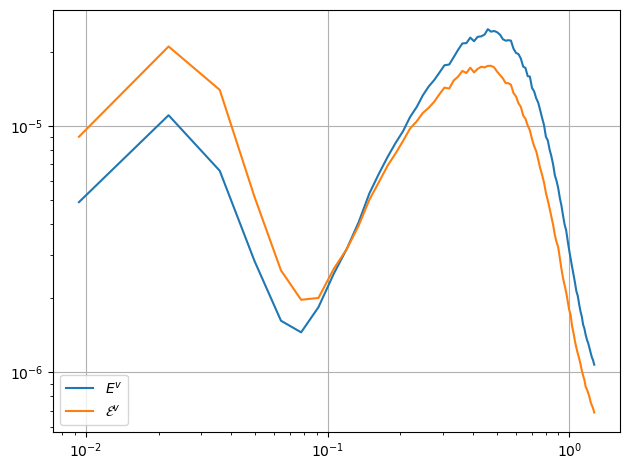

In [11]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
ax.plot(Fwp.freq_r*1e3, Fwp.isel(z_aaf=izc).mean("time"), label=r"$E^v$")
ax.plot(Fws.freq_r*1e3, Fws.mean("time"), label=r"$\mathcal{E}^v$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left")
ax.grid(True)

In [12]:
Zp = xrft.isotropic_power_spectrum(dspp.Pip.isel(z_aac=izc).chunk({"y_aca":-1,"x_caa":-1}), 
                                   dim=["y_aca","x_caa"], detrend="constant", 
                                   truncate=True
                                  )
Zs = xrft.isotropic_power_spectrum(dspp.Piflat.isel(z_aac=izc).chunk({"y_aca":-1,"x_caa":-1}), 
                                   dim=["y_aca","x_caa"], detrend="constant", 
                                   truncate=True
                                  )
Zp, Zs

(<xarray.DataArray (time: 7, freq_r: 90)> Size: 5kB
 dask.array<getitem, shape=(7, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
     z_aac    float64 8B -391.6
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266,
 <xarray.DataArray (time: 7, freq_r: 90)> Size: 5kB
 dask.array<getitem, shape=(7, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
     z_aac    float64 8B -391.6
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266)

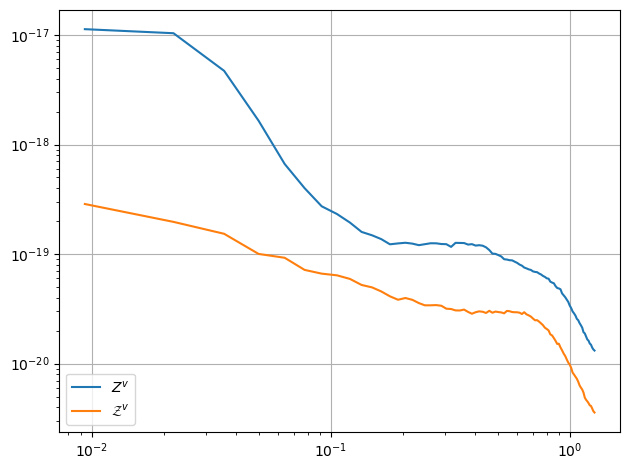

In [13]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
ax.plot(Zp.freq_r*1e3, Zp.mean("time"), label=r"$Z^v$")
ax.plot(Zs.freq_r*1e3, Zs.mean("time"), label=r"$\mathcal{Z}^v$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left")
ax.grid(True)

In [16]:
bp = (ds.b - ds.b.mean("time")).chunk({"y_aca":-1, "x_caa":-1})
bflat = (ds.b - dspp.bhash).chunk({"y_aca":-1, "x_caa":-1})
bflat

/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/dask/array/core.py:5003: PerformanceWarning: Increasing number of chunks by factor of 64
  result = blockwise(


<xarray.DataArray (time: 7, z_aac: 64, y_aca: 512, x_caa: 512)> Size: 940MB
dask.array<rechunk-merge, shape=(7, 64, 512, 512), dtype=float64, chunksize=(1, 1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) timedelta64[ns] 56B 360 days 00:00:20 ... 420 days
  * x_caa    (x_caa) float64 4kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
  * y_aca    (y_aca) float64 4kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
  * z_aac    (z_aac) float64 512B -1.939e+03 -1.82e+03 ... -15.77 -5.251

In [ ]:
(iks, ike) = (3,izc+1)
for ik in range(iks,ike):
    if ik == iks:
        Cp = xrft.isotropic_cross_spectrum(grid.interp(wp,"Z",boundary="extend"
                                                      ).isel(z_aac=ik),
                                           bp.isel(z_aac=ik),
                                           dim=["y_aca","x_caa"], detrend="constant", 
                                           truncate=True
                                          ).real
        Cf = xrft.isotropic_cross_spectrum(grid.interp(dspp.wflat.chunk({"z_aaf":-1}),
                                                       "Z",boundary="extend"
                                                      ).isel(z_aac=ik),
                                           bflat.isel(z_aac=ik),
                                           dim=["y_aca","x_caa"], detrend="constant", 
                                           truncate=True
                                          ).real
    else:
        Cp = xr.concat([Cp,
                        xrft.isotropic_cross_spectrum(grid.interp(wp,"Z",
                                                                  boundary="extend"
                                                                 ).isel(z_aac=ik),
                                                      bp.isel(z_aac=ik),
                                                      dim=["y_aca","x_caa"], 
                                                      detrend="constant", 
                                                      truncate=True
                                                     ).real
                       ], "z_aac")
        Cf = xr.concat([Cf,
                        xrft.isotropic_cross_spectrum(grid.interp(dspp.wflat.chunk({"z_aaf":-1}),
                                                                  "Z", boundary="extend"
                                                                 ).isel(z_aac=ik),
                                                      bflat.isel(z_aac=ik),
                                                      dim=["y_aca","x_caa"], 
                                                      detrend="constant", 
                                                      truncate=True
                                                     ).real
                       ], "z_aac")
Cp.coords["z_aac"] = ds.z_aac.isel(z_aac=slice(iks,ike))
Cf.coords["z_aac"] = ds.z_aac.isel(z_aac=slice(iks,ike))
Cp, Cf

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(Cp.freq_r*1e3, Cp.z_aac, Cp.mean("time"),
              vmax=1e-7, vmin=-1e-7, cmap="RdBu_r",
              rasterized=True)
axes[1].pcolormesh(Cf.freq_r*1e3, Cf.z_aac, Cf.mean("time"),
              vmax=1e-7, vmin=-1e-7, cmap="RdBu_r",
              rasterized=True)
axes[0].set_xscale("log")
axes[1].set_xscale("log")
# ax.legend(loc="lower left")
fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)

In [ ]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
im = ax.pcolormesh(Cp.freq_r*1e3, Cp.z_aac, 
                   Cf.mean("time") - Cp.mean("time"),
                   vmax=1e-7, vmin=-1e-7, cmap="bwr",
                   rasterized=True)
ax.set_xscale("log")
# ax.legend(loc="lower left")
fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.6)